# Homework 03

In this assignment, you will demonstrate your learning about creating data visualizations in Python using Seaborn. 

You should make sure any code that you write to answer the questions is included in this notebook. You are **required** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above will lose points.**

We will work with the `university_data.csv` dataset imported into the `uni` DataFrame below. We then preview the first few rows. It contains information about 311 universities in the United States including average student test scores and gpa, tuition costs, the state in which the school is located, the ranking, etc.

In [1]:
# Run but do not modify this code
try:
    import seaborn as sns
    print(sns.__version__, "# If you are running a version < 0.11, the next cell will not work! Make sure to update your seaborn library")
except Exception as e:
    %pip install seaborn
    import seaborn as sns

0.13.2 # If you are running a version < 0.11, the next cell will not work! Make sure to update your seaborn library


In [2]:
# Run but do not modify this code
sns.set_theme()
sns.set_context('talk')

In [3]:
# Run but do not modify this code
import pandas as pd
sns.set_theme()
uni = pd.read_csv("university_data.csv")
print(uni.shape)
uni.head()

(311, 13)


,act_avg,sat_avg,enrollment,city,acceptance_rate,percent_receiving_aid,cost_after_aid,state,hs_gpa_avg,tuition,Institution_name,institution_type,us_rank
0,32.0,1400.0,5400.0,Princeton,7.0,60.0,16793.0,NJ,3.9,47140,Princeton University,private,1.0
1,32.0,1430.0,6710.0,Cambridge,5.0,55.0,16338.0,MA,4.0,48949,Harvard University,private,2.0
2,32.0,1450.0,5941.0,Chicago,8.0,42.0,27767.0,IL,4.0,54825,University of Chicago,private,3.0
3,32.0,1420.0,5472.0,New Haven,6.0,50.0,18385.0,CT,NaN,51400,Yale University,private,3.0
4,32.0,1430.0,6113.0,New York,6.0,48.0,21041.0,NY,NaN,57208,Columbia University,private,5.0


### Question 1 (16 points total, 4 points per sub-question)
1. Generate a scatterplot of `tuition` on the horizontal `x` axis and `sat_avg` on the vertical `y` axis.
2. Generate the same scatterplot as in step 1, but color the points according to `institution_type`.

In the cell after the cell that says "Answer 1".

3. Pick a dot in the scatterplot from step 2 and write out what that dot represents.
4. Briefly interpret the two visualizations.
    1. What does it show about the correlation between `tuition` and `sat_avg`?
    2. What does it show about the difference between `public` and `private` institutions?

<!-- BEGIN QUESTION -->



<Axes: xlabel='tuition', ylabel='sat_avg'>

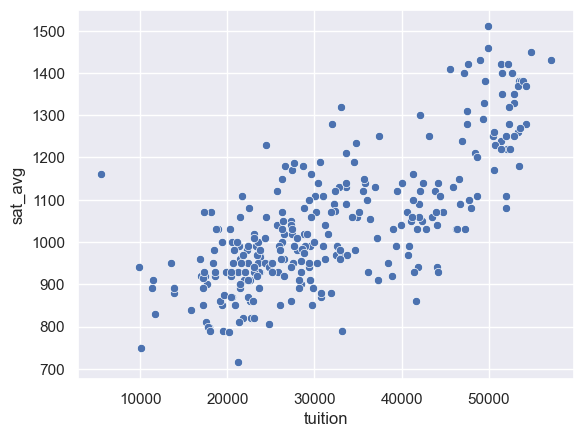

In [4]:
# Put your code for question 1.1 here
sns.scatterplot(data=uni, x="tuition", y="sat_avg")

<Axes: xlabel='tuition', ylabel='sat_avg'>

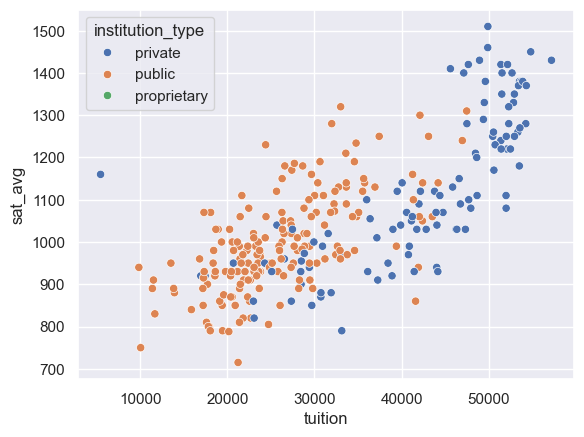

In [5]:
# Put your code for question 1.2 here
sns.scatterplot(data=uni, x="tuition", y="sat_avg", hue="institution_type")

<!-- END QUESTION -->

### Answer 1

The bottom-left-most orange dot in the scatterplot represents a public institution that costs $10000 in tuition to attend, and the average SAT of attendees was approximately 760. 

The scatterplot visualization shows a moderate-to-strong positive correlation between tuition and average SAT score. This indicates that as the cost of tuition increases, the average SAT score of the student body also increases.

The visualization shows that private institutions generally occupy the higher end of the plot in both tuition and average SAT score. Conversely, public schools tend to occupy the lower end, generally having lower average SAT scores and tuition compared to private schools.

<!-- END QUESTION -->

### Question 2.1 (4 points)

Below, we plot a histogram of `hs_gpa_avg`, the average high school gpa, for the schools. We set the `bins` manually. Identify at least two problems with our setting of `bins` that make the histogram difficult to read and or misleading. You do not need to replot the histogram to answer this question, but you are welcome to modify the `bins` parameter to see what different settings would give you in the visualization. Put your answer in `Answer 2.1` cell.

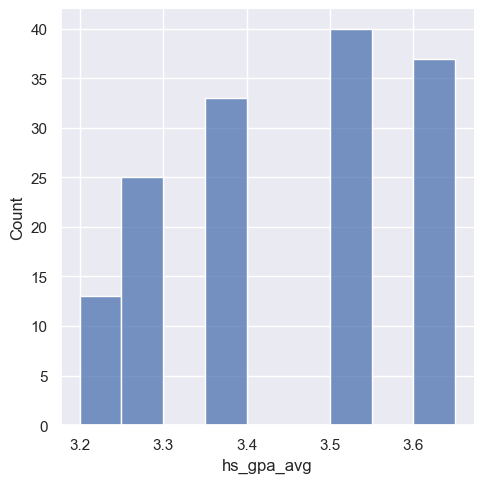

In [6]:
# Run this code, can modify to experiment but not required, answer below
sns.displot(data=uni, x="hs_gpa_avg", bins=[3.2 + 0.05*i for i in range(10)])

### Answer 2.1

The first problem with this histogram's bins is that it is set using list comprehension with a range. This range is set to start at a GPA average of 3.2 and stop at a GPA average of 3.65. This means that any gpa average below 3.20 and above 3.65 are completely excluded from the visualization, potentially skewing conclusions drawn from data sample. 

The second problem with histogram's bins is that there are noticeable gaps inbetween bars in the histogram. Because the bin width is set to a narrow 0.05, it is harder to observe the total distribution structure of the data as the empty intervals fragment the data and make it more difficult to read.

<!-- END QUESTION -->

### Question 2.2 (4 points)

Below we plot a heat map that visualizes the relationship between `hs_gpa_avg` on the horizontal `x` axis and `sat_avg` on the vertical `y` axis. It looks like there is a strong relationship between `hs_gpa_avg` and `sat_avg`. Suppose someone interprets this plot by saying "Look, every student who has a good high school gpa of 3.75 or above gets a SAT score of at least 900 or so." Why is this not necessarily true? Put your answer in "Answer 2.2" cell.

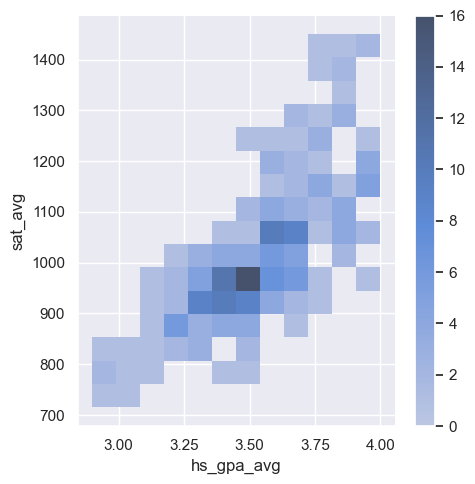

In [7]:
# Run this code, can modify to experiment but not required, answer below
sns.displot(data=uni, x="hs_gpa_avg", y="sat_avg", cbar=True)

### Answer 2.2

This is not necessarily true because both the `x` axis and `y` axis are an average of high school GPA and SAT score respectively. This means that each point on the heat map represents an entire school's performance, not any individual student's. 

<!-- END QUESTION -->

### Question 3 (16 points total, 4 points per sub-question, 2 autograder 14 manual points)
1. Generate a bar plot showing the difference in the distribution of `hs_gpa_avg` between `public` and `private` schools. That is, there should be two bars showing the average values with confidence intervals of `hs_gpa_avg` for `public` vs. `private` schools. There are a small number of `proprietary` schools in the dataset which are missing data in this category; filter those out so they do not appear in this visualization. Put the filtered data in `no_proprietary`.

2. Visualize the same information as in step 1, but using a box plot to visualize the distributions. As in step 1, do not include `proprietary` schools in the visualization.

In "Answer 3" cell:

3. Pick either private or public and write out what the corresponding bar and box plot means.
4. Briefly compare the plots, especially explaining what information the box plot visualizes that was not clear in the earlier bar plot.

<Axes: xlabel='institution_type', ylabel='hs_gpa_avg'>

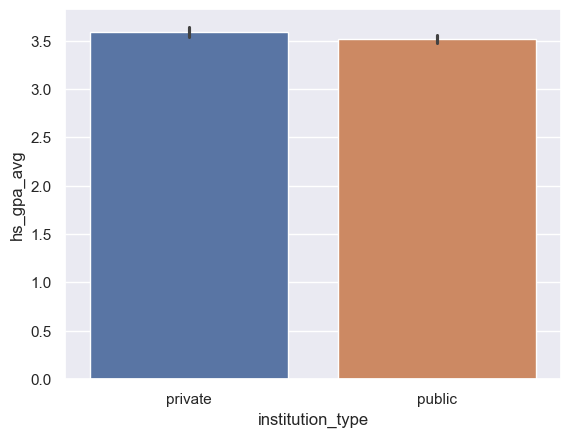

In [8]:
# Put your code for 3.1 here

no_proprietary = uni.loc[uni["institution_type"] != "proprietary"]
sns.barplot(data=no_proprietary, x="institution_type", y="hs_gpa_avg", hue="institution_type")

<Axes: xlabel='institution_type', ylabel='hs_gpa_avg'>

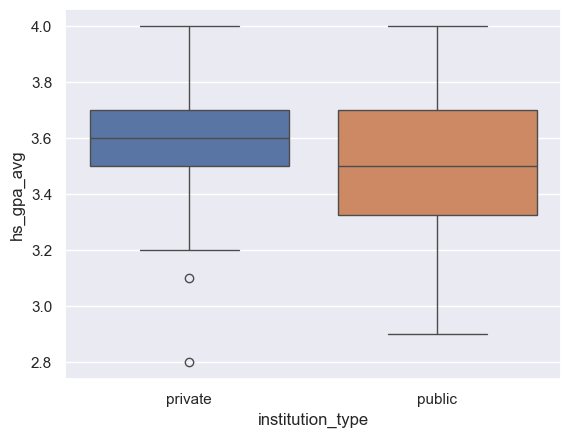

In [9]:
# Put your code for 3.2 here
sns.boxplot(data=no_proprietary, x="institution_type", y="hs_gpa_avg", hue="institution_type")

### Answer 3

The left blue bar in the bar plot represents the average high school GPA for private institution students, which sits around 3.6. The short error bar represents more reliable and less variable data as a whole. The left blue box in the box plot represents a more in depth summary of the same information. The horizontal middle line in the blue box represents the 50th percentile of students, ie, half the students have a GPA above 3.6 and half have a GPA below 3.6. The blue box represents the middle 50% of the data, ie, from the 25th to the 75th percentile. The vertical whiskers extend up and down to represent the rest of the distribution and the two dots at the bottom are outliers, representing students with significantly lower GPAs of around 2.8 and 3.1.

The box plot visualizes more significant amount more information than the bar plot. Firstly, the bar plot makes it seem as though private and public institutions have nearly identical high school GPA averages, however the box plot shows that private institutions have a tighter spread of GPAs towards the middle 50% as opposed to public institutions which have a larger spread, represented by a a longer box. The bar plot completely hides any indication of outliers, while the box plot visualizes two outliers. Lastly, the bar plot only gives us the singular average while the box plot allows additional observations of range and spread.

<!-- END QUESTION -->

### Question 4 (12 points total, 4 points per sub-question)
1. Generate a line plot of `us_rank` on the horizontal `x` axis and `tuition` on the vertical `y` axis. The plot should have the confidence intervals visible (light colored area around the dark line), which is the default setting in `seaborn`.
2. In a single figure, plot the same line as in step 2 in one color and another line for `cost_after_aid` on the vertical `y` axis in a different color. Use the same `us_rank` ordering on the horizontal `x` axis for both. Note that you may need to wrangle your data somewhat to produce this on the same plot rather than directly using the `uni` dataframe.
3. In step 2 we plotted `tuition` and `cost_after_aid` on the same vertical `y` axis. Briefly explain why that was reasonable, but it would not make sense to plot `tuition` and `enrollment` on the same vertical `y` axis in the same way. Explain in "Answer 4" cell.

<!-- BEGIN QUESTION -->



<Axes: xlabel='us_rank', ylabel='tuition'>

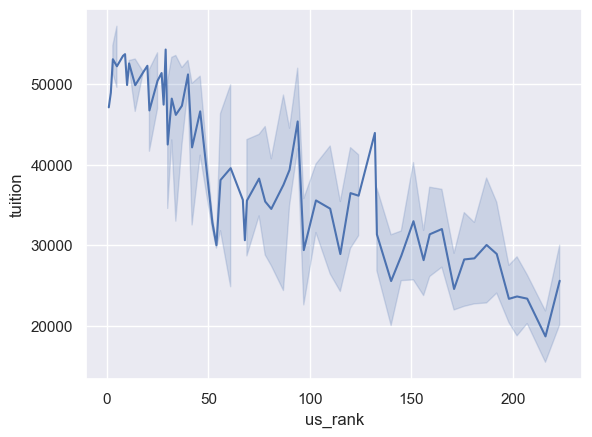

In [10]:
# Put your code for 4.1 here
sns.lineplot(data=uni, x="us_rank", y="tuition")

<Axes: xlabel='us_rank', ylabel='cost_after_aid'>

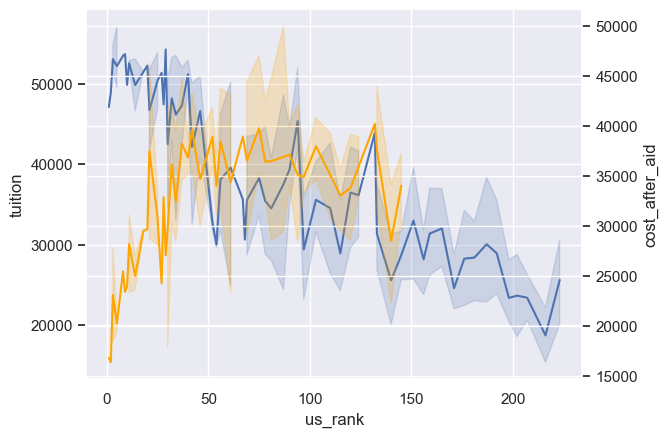

In [11]:
# Put your code for 4.2 here
import matplotlib.pyplot as plt

sns.lineplot(data=uni, x="us_rank", y="tuition")
ax2 = plt.twinx()
sns.lineplot(data=uni, x="us_rank", y="cost_after_aid", color='orange', ax=ax2)

<!-- END QUESTION -->

### Answer 4

It was reasonable to have plotted `tuition` and `cost_after_aid` on the same vertical `y` axis because they share the same unit of measurement and the same scale. Since they are both measured and USD ad, since they are both a cost for attendance, they must share the same range. Additionally, plotting the two of them on the `y` axis allows for a direct comparison of financial aid's effect relative to base cost of attendnace.

It would not make sense to plot `tuition` and `enrollment` on the same vertical `y` axis in the same way because they do not share either the same unit of measurement or same scale. Tuition is measured in USD and enrollment is measured in number of people. They cannot be meaningfully compared on the same `y` axis. Additionally, while it would make sense for a school to cost $50,000, it wouldn't be reasonable to expect a school to have 50,000 students enrolled. Because of this, if the two shared the same `y` axis, it would be difficult to read as the count of students would be significantly smaller for any given school.

<!-- END QUESTION -->

### Question 5 (18 points, 16 manual points)

Having now explored the data in various ways, in this question, you will analyze the data yourself by doing the following:
1. Add a new column using at least 2 columns, which is a new statistic about the data per row. Put the new column's name in `new_stat_name`.
2. Plot this new column with a visualization of your choice. You may use other columns as well in the visualization if it helps explain your new column.

In the written part of this question, provide an explanation of the following:
1. What does your statistic mean in your `new_stat_name` column?
2. How to calculate your new per-row statistic.
3. Pick a single spot on the plot and describe it by filling out the sentence "The __ on the chart means __ ." (you may use these exact words)

    a. Make sure it is clear what spot you are referring to and you are "pointing" it out without using its data values (otherwise, that's like defining a word while using the word in the definition). For example, "the top right blue dot" or "the shortest red bar," as opposed to "the top right public school dot" or the "the bar for Princeton."
    
    b. If using something like a histogram, be precise about what is inclusive vs. exclusive. For example, “it includes up to 10” is not the same as “it includes up to and including 10.”
4. Why did you choose that function and use any deviations from the default behavior of that function? Discuss this at least partially in terms of the insight you sought from the plot.


<Axes: xlabel='institution_type', ylabel='avg_aid_amt'>

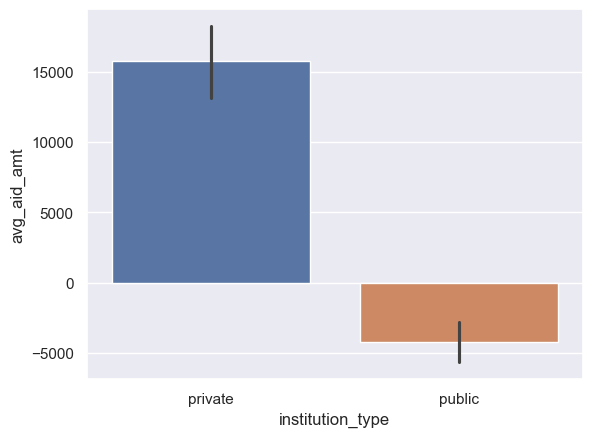

In [12]:
# Put your code for question 5 here
new_stat_name = "avg_aid_amt"

uni[new_stat_name] = uni["tuition"] - uni["cost_after_aid"]
no_proprietary = uni.loc[uni["institution_type"] != "proprietary"]

sns.barplot(data=no_proprietary, x="institution_type", y=new_stat_name, hue="institution_type")

### Answer 5

My new statistic, `avg_aid_amt` represents the average amount of financial aid that students recieve at any given institution. It is the difference between the cost of attendance before and after aid in order to quantify the amount of financial aid recieved.

To calculate this, you subtract `cost_after_aid` from the total `tuition` in order to get that difference.

The left blue bar means that for private institutions, the average finanical aid recieved by students is around $16000.

I chose a barplot function because it is optimally designed for observing numerical data totaled across categories for comparison. Regarding deviations, I firstly used `.loc` to filter out `proprietary` institutions to focus on the most comparable categories. I used `hue` to separate the institution between `private` and `public`. Additionally I used the native error bars in order to provide insight on the spread of the data, which indicates that private institutions vary far more in their aid amount provided, whereas public insitutions have more "structured" costs.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# AI Disclosure

Use the **Artificial Intelligence Disclosure (AID) Framework** to explain your use of AI on this assignment. Other headings you can use include:

- *Debugging:* Using AI to help you fix your code so that it works. You should state how you used it for this purpose.

Here are some examples:

*Artificial Intelligence Tools:* ChatGPT v5 via chatgpt.com. *Conceptualization:* I gave chatgpt.com the election data set and asked it for ideas on interesting statistics I could get from the data. *Methodology:* I asked it for help on how to write the code to get the statistic I chose, but I wrote the code myself. *Writing — Review & Editing:* I wrote out my explanation for what the statistic meant, then gave that text and the rubric to chatgpt and asked it to give me feedback on how to update the explanation to conform to the rubric.

*Artificial Intelligence Tools:* ChatGPT v4o via DukeGPT. *Information Collection:* DukeGPT was used to find the function needed to get the index value of the maximum value of a Series and the syntax needed to filter rows in a pandas dataframe using multiple columns. *Debugging:* DukeGPT was used to help me find a bug in my code for Q1 where I copied in the code and error, stated what the code should do, and asked for help.

**Solution** *Artificial Intelligence Tools:* Google Gemini. Writing—Review & Editing: Proofreading and editing of my answers in order to ensure written responses abide by the question rubric.

<!-- END QUESTION -->

## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **required** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above will lose points.**